In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.models import NaiveDrift, NaiveSeasonal, ExponentialSmoothing
from darts.metrics import mae, rmse, mape
from darts.metrics import mape

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_html("ReporteTempPDI_1763779315451.xls")[0]

In [4]:
# Renombrar columnas si tienen múltiples niveles
df.columns = df.columns.droplevel(0) if isinstance(df.columns, pd.MultiIndex) else df.columns
df.columns = ["n", "año", "mes", "Llegadas_total", "var_12_meses"]

In [5]:
import locale
from datetime import datetime

# Cambiar temporalmente a español
locale.setlocale(locale.LC_TIME, 'es_ES.UTF-8')  # o 'es_CO.UTF-8' si estás en Colombia

# Ejemplo directo
fecha = datetime.strptime("2023-DICIEMBRE", "%Y-%B")
print(fecha)

2023-12-01 00:00:00


In [6]:
# Filtrar filas válidas
df = df[df["año"].apply(lambda x: str(x).isdigit())]
df = df[df["mes"].notna()]
df["mes"] = df["mes"].str.upper()

# Construcción de columna fecha
df["fecha"] = pd.to_datetime(df["año"].astype(str) + "-" + df["mes"], format="%Y-%B")
# Establecer fecha como índice
df = df.set_index("fecha").sort_index()
# Asegurar frecuencia mensual en el índice
df = df.asfreq("MS")

In [7]:
# Convertir llegadas a numérico (puede hacerse antes o después)
df["Llegadas_total"] = pd.to_numeric(df["Llegadas_total"], errors="coerce")

# División del set de datos: Train / Test

In [8]:
# Convertir el DataFrame pandas a un objeto TimeSeries de Darts
df_series = TimeSeries.from_dataframe(df, value_cols="Llegadas_total")

# División según criterios: TRAIN hasta 2022-12, TEST desde 2023-01
df_train, df_val = df_series.split_before(pd.Timestamp("2023-10"))

# Crear modelos

In [9]:
# 1. Ajustar modelo Naive con deriva
naive_drift_model = NaiveDrift()
naive_drift_model.fit(df_train)

# 2. Hacer predicción
drift_forecast = naive_drift_model.predict(len(df_val))

# 3. Calcular métricas
mae_drift = mae(df_val, drift_forecast)
rmse_drift = rmse(df_val, drift_forecast)
mape_drift = mape(df_val, drift_forecast)

print(f"MAE: {mae_drift:.2f}")
print(f"RMSE: {rmse_drift:.2f}")
print(f"MAPE: {mape_drift:.2f}%")

MAE: 217.56
RMSE: 255.60
MAPE: 44.09%


In [10]:
# Crear modelo con periodicidad estacional de 12 meses (anual)
naive_seasonal_model = NaiveSeasonal(K=12)
naive_seasonal_model.fit(df_train)

# Predecir para el mismo número de pasos que df_val
naive_seasonal_forecast = naive_seasonal_model.predict(len(df_val))

# Métricas
mae_seasonal = mae(df_val, naive_seasonal_forecast)
rmse_seasonal = rmse(df_val, naive_seasonal_forecast)
mape_seasonal = mape(df_val, naive_seasonal_forecast)

print("SEASONAL NAIVE:")
print(f"MAE: {mae_seasonal:.2f}")
print(f"RMSE: {rmse_seasonal:.2f}")
print(f"MAPE: {mape_seasonal:.2f}%")


SEASONAL NAIVE:
MAE: 154.74
RMSE: 176.90
MAPE: 32.81%


In [11]:
# Crear y ajustar el modelo STL básico (ETS)
stl_model = ExponentialSmoothing()
stl_model.fit(df_train)

# Predecir
stl_forecast = stl_model.predict(len(df_val))

# Métricas
mae_stl = mae(df_val, stl_forecast)
rmse_stl = rmse(df_val, stl_forecast)
mape_stl = mape(df_val, stl_forecast)

print("STL (Exponential Smoothing):")
print(f"MAE: {mae_stl:.2f}")
print(f"RMSE: {rmse_stl:.2f}")
print(f"MAPE: {mape_stl:.2f}%")



STL (Exponential Smoothing):
MAE: 76.07
RMSE: 90.37
MAPE: 15.73%


# Gráficos

In [12]:
def plot_fitted_vs_actual(model_name, train, val, forecast, color):
    plt.figure(figsize=(12, 5))
    
    # Serie completa real
    train.plot(label="Entrenamiento", lw=2, color="black")
    
    # Validación (solo para referencia visual)
    val.plot(label="Validación", lw=2, color="gray", linestyle="--")
    
    # Predicción del modelo sobre todo el test
    forecast.plot(label=f"{model_name} - Ajuste", lw=2, color=color)
    
    # Decoración
    plt.title(f"Ajuste del modelo {model_name} (Train + Test)", fontsize=14)
    plt.xlabel("Fecha")
    plt.ylabel("Llegadas Totales")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


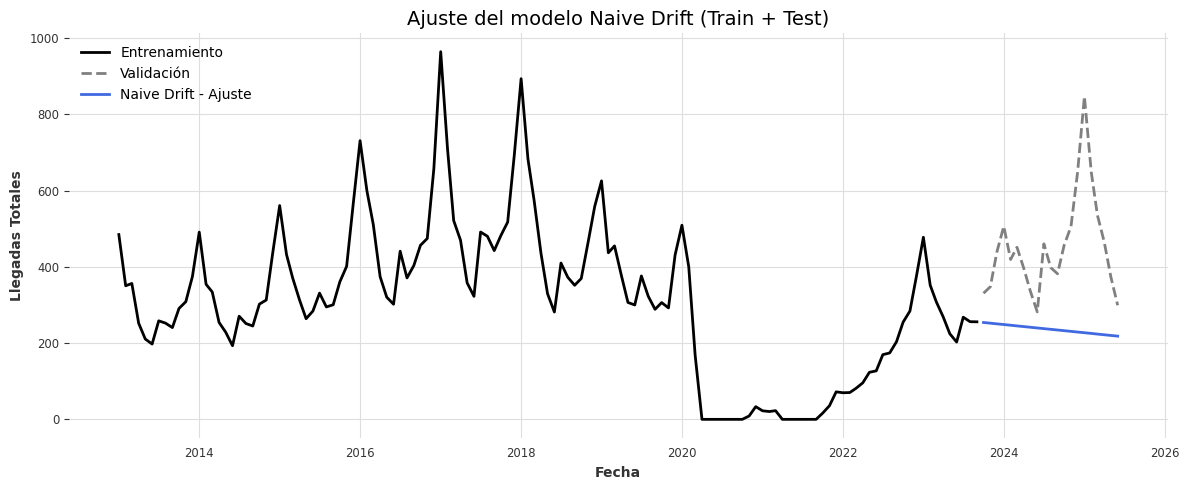

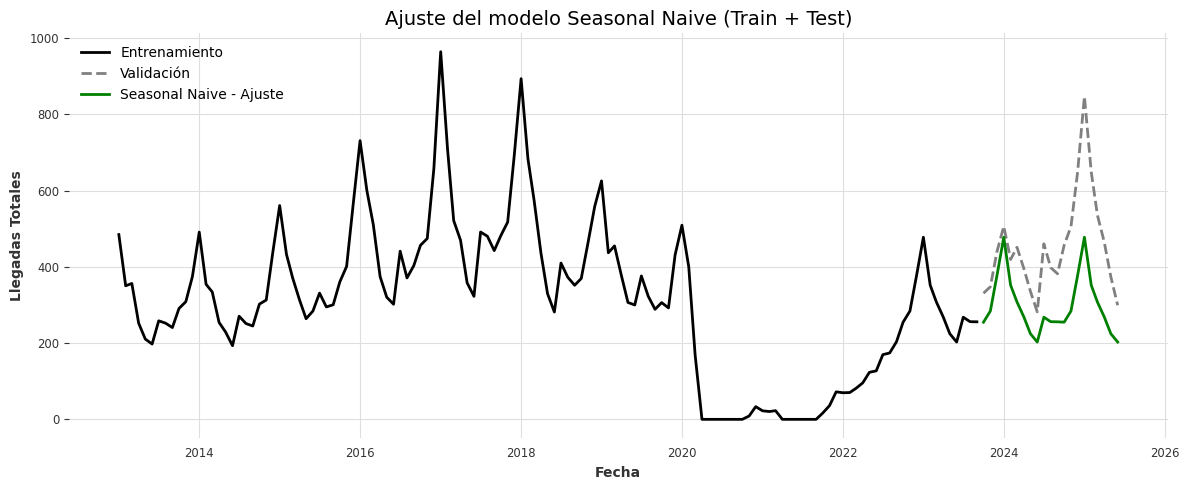

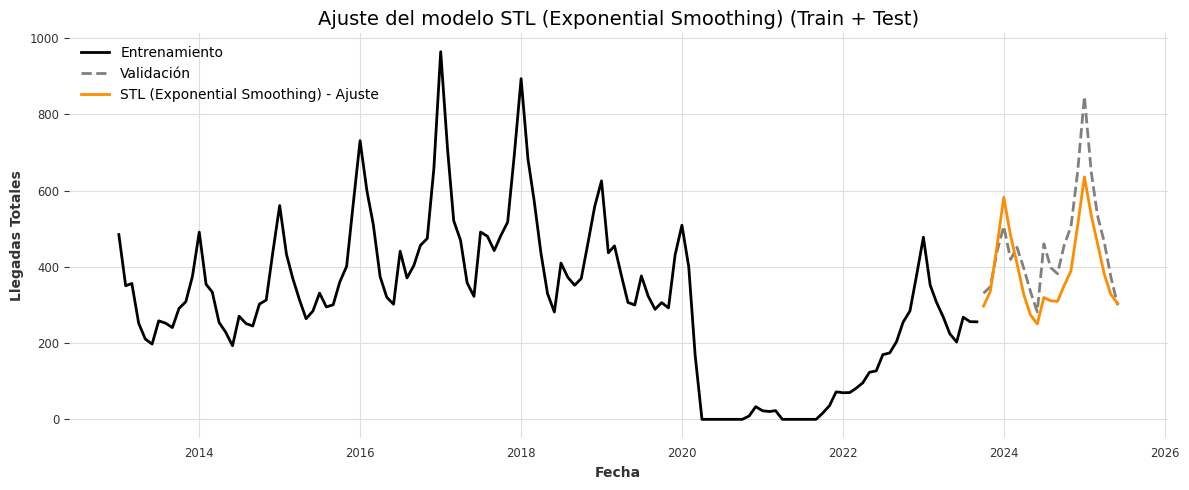

In [13]:
# Gráficos separados por modelo
plot_fitted_vs_actual("Naive Drift", df_train, df_val, drift_forecast, "royalblue")
plot_fitted_vs_actual("Seasonal Naive", df_train, df_val, naive_seasonal_forecast, "green")
plot_fitted_vs_actual("STL (Exponential Smoothing)", df_train, df_val, stl_forecast, "darkorange")

# Horizonte del pronóstico 

In [14]:
# Modelo 1: Naive Drift
drift_forecast_6 = naive_drift_model.predict(6)
drift_forecast_12 = naive_drift_model.predict(12)

# Modelo 2: Seasonal Naive (K=12 meses)
seasonal_forecast_6 = naive_seasonal_model.predict(6)
seasonal_forecast_12 = naive_seasonal_model.predict(12)

# Modelo 3: STL (Exponential Smoothing)
stl_forecast_6 = stl_model.predict(6)
stl_forecast_12 = stl_model.predict(12)

# Gráficos 

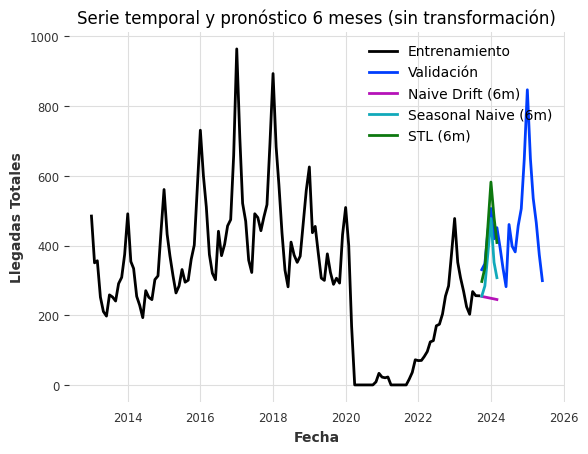

In [15]:
#TRAIN
df_train.plot(label="Entrenamiento", lw=2)

#TEST 
df_val.plot(label="Validación", lw=2)

# 3. Pronósticos a 6 meses por cada modelo
drift_forecast_6.plot(label="Naive Drift (6m)", lw=2)
seasonal_forecast_6.plot(label="Seasonal Naive (6m)", lw=2)
stl_forecast_6.plot(label="STL (6m)", lw=2)

# 4. Decoración como en clase
plt.title("Serie temporal y pronóstico 6 meses (sin transformación)")
plt.xlabel("Fecha")
plt.ylabel("Llegadas Totales")
plt.grid(True)
plt.legend()
plt.show()